# JDR clustering of 500 OGLE light curves

A reproducible, exploratory comparison of **K-medoids, K-means, average linkage, DBSCAN and HDBSCAN** using the same spectral geometry. This notebook recomputes the analysis, audits the spectral integrals, repeats the entire computation, and exports the four figure sets used in the 100-object experiment.

**Scope:** a new seeded sample of 500 original Galactic Disk I-band RR Lyrae light curves, not 400 synthetic additions to the earlier mixed-region census. The 100- and 500-object scores are not controlled sample-size comparisons. The lower period-search limit is explicitly extended from 0.20 to 0.15 days; other clustering policies are retained. Labels are used for cohort definition and post-fit assessment, never to optimize clustering settings. This is not held-out classification accuracy or a completed astrophysical validation of JDR.

**Execution:** calculations run in the local Python kernel, with one numerical thread. Public OGLE files are downloaded only during the separate acquisition step. The analysis has no cloud-compute dependency and does not silently reuse fitted shapes or distance matrices.

For a clean environment, install the recorded `results/benchmark_500/environment-lock.txt` with Python 3.12, then run this notebook from the repository. The general dependency files also support development; exact repeatability is tested within the recorded environment, not guaranteed across numerical-library versions.

In [1]:
from pathlib import Path
import os, sys, json, tempfile, time
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '1')
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'study500.py').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown
from src.study500 import DATA, PROTOCOL500, cohort500, run_study500, compare_study500
from src.benchmark import MODEL_NAMES
from src.publication_figures import make_figures
OUTPUT = ROOT / 'results' / 'benchmark_500'
display(pd.Series(PROTOCOL500, name='Predeclared protocol').to_frame())

Matplotlib is building the font cache; this may take a moment.


,Predeclared protocol
version,2
n_objects,500
seed,20260912
n_clusters,3
n_init,20
dbscan_min_samples,5
dbscan_eps_quantile,0.7
hdbscan_min_cluster_size,5
hdbscan_min_samples,5
subsamples,30


## 1. Data source, selection and management

The source is the [OGLE Collection of Variable Stars: Galactic Disk RR Lyrae](https://www.astrouw.edu.pl/ogle/ogle4/OCVS/gd/rrlyr/), described by [Soszyński et al. (2019), Acta Astronomica 69, 321](https://arxiv.org/abs/2001.00025). Cite the OGLE catalog when using these data. The frozen archive and catalogs are retained because the live catalog can change.

The acquisition script `scripts/prepare_ogle500.py` reads original I-band members from `phot.tar.gz`. It reads **fixed-width** IDs, subtypes and periods according to the archived README; whitespace splitting can misinterpret catalog rows with missing fields. RRab, RRc and RRd are in scope; anomalous RRd are not. A NumPy permutation of sorted candidate IDs, seed **20260912**, determines selection. We take the first 500 candidates passing the input checks and then sort by ID for every downstream array. This is an eligibility-conditioned random sample, not a subtype-balanced sample or a representative survey of all variable stars.

Requirements are at least 30 observations, finite times/magnitudes/errors, positive errors, distinct times, nonconstant magnitude, a catalog period, and unique IDs/content. Six of the first 506 candidates fail the observation-count threshold; all exclusions are retained. Individual measurements are not clipped, imputed or interpolated. The raw columns are time in days (OGLE HJD offset convention), I magnitude and its reported uncertainty in magnitudes. Per-star subtraction of the first epoch makes the additive time origin irrelevant to the period search.

| Location | Role |
|---|---|
| `data/ogle_gd_500/source/` | Original archive, README, identifications and period catalogs |
| `data/ogle_gd_500/photometry/` | 500 unmodified selected I-band files |
| `data/ogle_gd_500/cohort.csv` | Ordered IDs, relative paths, SHA-256 hashes, counts, baselines and catalog metadata |
| `acquisition.json`, `eligibility_exclusions.csv` | URLs, archive hashes, sampling policy and exclusion log |
| `results/benchmark_500/` | Recomputed fits, matrices, labels, metrics, diagnostics and provenance |
| `results/benchmark_500/figures/` | PDF/SVG/600-dpi PNG, previews and captions |

The old data and 100-object results remain separate. To acquire from scratch, run `python scripts/prepare_ogle500.py` from the repository. It reuses existing source files and reconstructs the same selection; compare source hashes with the archived manifest if downloading a later catalog snapshot.

In [2]:
files, selected, catalogs = cohort500()
assert len(files) == 500 and selected.object_id.is_unique and selected.sha256.is_unique
acquisition = json.loads((DATA / 'acquisition.json').read_text())
display(pd.crosstab(selected.region, selected.catalog_type, margins=True))
display(selected[['n_observations', 'baseline_days', 'catalog_period']].describe())
display(pd.read_csv(DATA / 'eligibility_exclusions.csv'))
print('Unique unordered distance pairs:', len(files) * (len(files)-1) // 2)
print('Raw observations:', int(selected.n_observations.sum()))

catalog_type,RRab,RRc,RRd,All
region,,,,
GD,394,101,5,500
All,394,101,5,500


,n_observations,baseline_days,catalog_period
count,500.000000,500.000000,500.000000
mean,121.752000,1607.838534,0.505095
std,32.541795,673.477581,0.133220
min,33.000000,206.634240,0.213992
25%,103.000000,918.725002,0.416936
50%,124.000000,1633.639715,0.517847
75%,146.250000,2266.701110,0.594047
max,212.000000,2515.856460,0.916822


,object_id,candidate_rank,reason
0,OGLE-GD-RRLYR-00757,71,Fewer than 30 observations for periodic shape ...
1,OGLE-GD-RRLYR-10308,86,Fewer than 30 observations for periodic shape ...
2,OGLE-GD-RRLYR-11518,184,Fewer than 30 observations for periodic shape ...
3,OGLE-GD-RRLYR-04129,244,Fewer than 30 observations for periodic shape ...
4,OGLE-GD-RRLYR-03432,332,Fewer than 30 observations for periodic shape ...
5,OGLE-GD-RRLYR-11628,404,Fewer than 30 observations for periodic shape ...


Unique unordered distance pairs: 124750
Raw observations: 60876


## 2. Period estimation and a common phase representation

For each star, the period search uses all original irregular observations and their uncertainties. A floating-mean Lomb–Scargle periodogram covers **0.15–2 days**, at five samples per nominal peak width. A 500,000-frequency cap fails explicitly instead of silently coarsening the search. The five strongest distinct local peaks are refined, along with their half- and double-period alternatives within the allowed band.

At every candidate, weighted least squares fits

$$m(t)=c+\sum_{h=1}^{H}\left[A_h\cos(2\pi h\phi(t))+B_h\sin(2\pi h\phi(t))\right],\quad
\phi(t)=\operatorname{frac}[(t-t_0)/P],\qquad H\in\{1,2,3,4\}.$$

Period and order minimize the implemented BIC-style criterion

$$\mathrm{BIC}=n\log(\mathrm{RSS}_w/n)+(2H+2)\log n,\qquad
\mathrm{RSS}_w=\sum_r[(m_r-\hat m_r)\sigma_{\min}/\sigma_r]^2.$$

The relative inverse-variance weights allow an unknown common residual scale; this criterion is not an absolute goodness-of-fit test for perfectly calibrated photometric errors. The complexity penalty discourages representing one period with unnecessary harmonics at twice the period. Candidate search is finite and can still miss the physical period.

The smooth fitted brightest phase (minimum magnitude, evaluated on 4,096 phase points) defines phase zero. The fitted curve is evaluated at **256 uniformly spaced phases** in $[0,1)$. These are samples of a model, not 256 new observations or interpolated raw measurements. This procedure intentionally focuses clustering on normalized shape, suppressing mean magnitude, absolute epoch, amplitude and period. Phase uncertainty, Blazhko modulation, multiple pulsation modes and cadence effects can still distort that shape. In particular, a single-period model is incomplete for RRd.

Catalog periods are withheld from fitting. After all models are fixed, we compare the fitted period with the catalog period (either mode for RRd), flag relative differences above 1%, and separately identify half/double aliases. Flags do not remove objects or alter the primary results. Inspect them before making astrophysical claims.

## 3. Spectral coefficients, integrals and the distance

Let $x_i(\phi_r)$ be the fitted phase curve for star $i$. Standardize it with its **population** standard deviation:

$$y_i(\phi_r)=\frac{x_i(\phi_r)-\overline{x_i}}{s_i}.$$

For each common frequency $f$, fit an intercept and both trigonometric components jointly:

$$y_i(\phi_r)\simeq c_i(f)+a_i(f)\cos(2\pi f\phi_r)+b_i(f)\sin(2\pi f\phi_r).$$

All stars use the same phase coordinate and frequency grid. The spectral fit is unweighted on the uniform model grid; raw measurement errors were used in the preceding period/shape fit and are not treated as independent errors of model-grid points. A floating intercept remains necessary at noninteger frequencies. The standard v2 coefficients are fitted amplitudes, not the historical unnormalized projections.

Define the real auto- and cross-spectral terms used here:

$$S_{ii}(f)=\tfrac12[a_i(f)^2+b_i(f)^2],\qquad
\operatorname{Re}S_{ij}(f)=\tfrac12[a_i(f)a_j(f)+b_i(f)b_j(f)].$$

On the predeclared common band $f\in[0.5,6]$ **cycles per phase unit**, let

$$I_i=\int_{0.5}^{6}S_{ii}(f)\,df,\quad I_j=\int_{0.5}^{6}S_{jj}(f)\,df,\quad I_{ij}=\int_{0.5}^{6}\operatorname{Re}S_{ij}(f)\,df.$$

With $\alpha=1/2$ and $\beta=\alpha(1-\alpha)=1/4$, the implemented squared JDR is

$$J_{ij}=\frac{\beta}{2\pi}(I_i+I_j-2I_{ij})
=\frac{\beta}{4\pi}\int_{0.5}^{6}\left[(a_i-a_j)^2+(b_i-b_j)^2\right]df.$$

The integration variable is $df$, not $d\omega$. Although the basis is evaluated with $\omega=2\pi f$, no extra Jacobian is applied. These integrals quantify the implemented representation; they are not a claim of calibrated physical power spectral density or a verified reproduction of an unidentified JDR paper.

For positive trapezoidal weights $q_k$ (interior $\Delta f$, endpoints $\Delta f/2$), define

$$z_i=\left[\sqrt{\frac{\beta q_k}{4\pi}}a_i(f_k),\ 
\sqrt{\frac{\beta q_k}{4\pi}}b_i(f_k)\right]_{k=1}^{M}.$$

Then **$J_{ij}\approx\|z_i-z_j\|_2^2$**. Every matrix-based method uses $D_{ij}=\sqrt{J_{ij}}$, which has the Euclidean triangle inequality in this embedding. K-means uses the full $z_i$ directly. It would be inconsistent to feed squared distances to some methods and Euclidean distances to others.

This also explains the speed: coefficients are computed once per star and grid, then all **124,750** unique pairs are evaluated as vector differences. We do not launch three expensive adaptive integrals independently for every pair. At $M=4097$, there are 8,194 features per star (about 32.8 MB for 500 float64 feature vectors). The 500-by-500 matrix is about 2 MB; several grids and intermediate arrays increase peak memory.

**Numerical validation:** recompute at 1,025, 2,049 and 4,097 frequencies; require every matrix entry to agree at `rtol=1e-3, atol=1e-8` and all nearest-neighbor identities to agree between consecutive grids. Recompute features after an object permutation to test ordering. Independently use adaptive SciPy quadrature for all three spectral integrals of three reproducibly selected pairs near the 10th, 50th and 90th distance percentiles. Failed quadrature or failed comparisons stop execution. Three pairs audit the integral identity; the grid check covers every pair, and neither establishes astrophysical validity.

## 4. Predeclared clustering comparison

| Method | Input and fixed policy |
|---|---|
| K-medoids | $D$; $K=3$; best distance-sum objective of 20 seeded starts |
| K-means | Full spectral embedding $z$; $K=3$; 20 seeded starts |
| Average linkage | $D$; agglomeration cut at $K=3$ |
| DBSCAN | $D$; minimum samples 5 including self; $\epsilon$ is the 70th percentile of the corresponding per-star neighbor distances |
| HDBSCAN | $D$; minimum cluster size 5; minimum samples 5 |

$K=3$ is an explicit comparison assumption motivated by the three catalog subtypes, not an inferred optimal number of physical populations. Density methods may find a different number of clusters or label stars as noise. The custom DBSCAN result must exactly match scikit-learn on this cohort.

Report ARI and AMI against catalog subtypes on all stars, coverage, assigned-only purity/ARI and silhouette. Noise remains a shared label −1 in all-star agreement scores; coverage and subtype retention expose selection effects. Purity alone is insufficient with a majority RRab class. Galactic-region agreement is undefined here because every star is GD.

Stability uses 30 shared seeded subsets of **400 stars**, refitting each method with the same policies; DBSCAN recalculates its prescribed distance quantile within each subset. Empirical 10th–90th percentiles describe sensitivity to removing stars, **not confidence intervals or photometric uncertainty**. The full DBSCAN grid of 3 neighborhood sizes × 18 quantiles is descriptive and does not select the primary settings. PCA is a two-dimensional figure only; clustering uses the full representation.

In [3]:
run_study500(OUTPUT)
summary = json.loads((OUTPUT / 'summary.json').read_text())
scores = pd.read_csv(OUTPUT / 'model_comparison.csv').set_index('model').loc[MODEL_NAMES]
cohort_table = pd.read_csv(OUTPUT / 'cohort.csv')
with np.load(OUTPUT / 'experiment.npz', allow_pickle=False) as archive:
    D, J = archive['distance'].copy(), archive['J'].copy()
    assert archive['features'].shape == (500, 8194)
    assert archive['object_ids'].tolist() == selected.object_id.tolist()
assert D.shape == (500, 500) and np.isfinite(D).all()
assert np.array_equal(np.diag(D), np.zeros(500))
assert np.all(D >= 0) and np.allclose(D, D.T) and np.allclose(D**2, J)
assert summary['permutation_invariance'] and summary['fit_info']['dbscan_reference_agreement']
display(pd.DataFrame(summary['grid_convergence']))
display(pd.read_csv(OUTPUT / 'spectral_integral_audit.csv'))
display(pd.Series(json.loads((OUTPUT / 'timing.json').read_text()), name='Measured runtime').to_frame())

Folded 20/500 light curves


Folded 40/500 light curves


Folded 60/500 light curves


Folded 80/500 light curves


Folded 100/500 light curves


...

Folded 480/500 light curves


Folded 500/500 light curves


,coarse_grid,fine_grid,relative_max_error,all_pairs_close,neighbor_agreement
0,1025,2049,0.000009,True,1.0
1,2049,4097,0.000002,True,1.0


,distance_quantile,object_i,object_j,integral_xx,integral_yy,integral_xy,j_adaptive,j_grid,absolute_difference,relative_difference,passed
0,0.1,OGLE-GD-RRLYR-08772,OGLE-GD-RRLYR-09927,1.174869,1.120733,1.140084,0.000614,0.000614,8.209829e-10,1.336783e-06,True
1,0.5,OGLE-GD-RRLYR-04404,OGLE-GD-RRLYR-08364,1.277136,1.178985,1.161301,0.005313,0.005313,2.938939e-10,5.532060e-08,True
2,0.9,OGLE-GD-RRLYR-01832,OGLE-GD-RRLYR-10539,1.610400,1.106498,0.972442,0.030717,0.030718,2.213032e-08,7.204468e-07,True


,Measured runtime
elapsed_seconds,86.814716
scope,"Full 500-object fits, three spectral grids, pe..."
execution,Local Python process; one numerical thread; no...


## 5. Results and period diagnostic

The following values are computed from these 500 curves. Inspect disagreement with catalog periods alongside clustering scores: a clean numerical result can still reflect a poor physical period or a restrictive shape model.

In [4]:
display(scores[['ari_all', 'ami_all', 'coverage', 'n_clusters', 'n_noise', 'purity_assigned', 'ari_assigned', 'silhouette_assigned']].round(4))
retention = pd.DataFrame({name: summary['models'][name]['class_retention'] for name in MODEL_NAMES}).T
display(retention.rename_axis('model').round(3))
periods = pd.read_csv(OUTPUT / 'period_audit.csv')
display(periods.groupby('catalog_type').agg(n=('object_id', 'size'), within_1_percent=('agrees_within_1_percent', 'sum'), half_double_aliases=('half_double_alias_only', 'sum')))
display(periods.loc[~periods.agrees_within_1_percent].sort_values('relative_error_nearest_mode', ascending=False))
checks = json.loads((OUTPUT / 'additional_checks.json').read_text())
assert checks['spectral_integrals_passed']
print(checks['period_diagnostic'])

,ari_all,ami_all,coverage,n_clusters,n_noise,purity_assigned,ari_assigned,silhouette_assigned
model,,,,,,,,
K-medoids,0.5424,0.4930,1.000,3,0,0.9240,0.5424,0.5086
K-means,0.5513,0.4979,1.000,3,0,0.9300,0.5513,0.5051
Average linkage,0.5363,0.4914,1.000,3,0,0.9300,0.5363,0.4949
DBSCAN,0.3840,0.3773,0.804,8,98,0.9801,0.6460,0.4963
HDBSCAN,0.4113,0.3886,0.810,8,95,0.9778,0.6881,0.4803


,RRab,RRc,RRd
model,,,
K-medoids,1.000,1.000,1.0
K-means,1.000,1.000,1.0
Average linkage,1.000,1.000,1.0
DBSCAN,0.805,0.802,0.8
HDBSCAN,0.807,0.822,0.8


,n,within_1_percent,half_double_aliases
catalog_type,,,
RRab,394,387,0
RRc,101,99,0
RRd,5,4,0


,object_id,catalog_type,fitted_period,catalog_period,catalog_secondary_period,relative_error_nearest_mode,relative_error_half_double,agrees_within_1_percent,half_double_alias_only
438,OGLE-GD-RRLYR-10205,RRab,1.023375,0.505080,NaN,1.026165,0.013082,False,False
380,OGLE-GD-RRLYR-09053,RRab,0.674219,0.402267,NaN,0.676050,0.161975,False,False
148,OGLE-GD-RRLYR-03625,RRab,0.394016,0.651379,NaN,0.395105,0.209789,False,False
28,OGLE-GD-RRLYR-00773,RRab,0.344382,0.526043,NaN,0.345334,0.309333,False,False
33,OGLE-GD-RRLYR-00847,RRab,0.327932,0.488594,NaN,0.328824,0.342352,False,False
37,OGLE-GD-RRLYR-00946,RRab,0.321354,0.474147,NaN,0.322248,0.355503,False,False
492,OGLE-GD-RRLYR-11500,RRab,0.300387,0.429891,NaN,0.301248,0.397504,False,False
208,OGLE-GD-RRLYR-04983,RRc,0.267145,0.364889,NaN,0.267874,0.464253,False,False
398,OGLE-GD-RRLYR-09400,RRc,0.266252,0.363228,NaN,0.266983,0.466034,False,False
42,OGLE-GD-RRLYR-01000,RRd,0.618836,0.381885,0.512272,0.208024,0.189760,False,False


{'n_objects': 500, 'within_1_percent': 490, 'half_double_alias_only': 0, 'interpretation': 'Descriptive post-fit check, including either catalog mode for RRd; not used to change fits, exclude objects or select clustering.'}


In [5]:
stability = pd.read_csv(OUTPUT / 'subsampling_stability.csv')
assert len(stability) == 30 * len(MODEL_NAMES)
memberships = json.loads((OUTPUT / 'subsample_membership.json').read_text())
assert len(memberships) == 30 and all(len(set(ids)) == 400 for ids in memberships)
stability_summary = stability.groupby('model')['ari_stability_all'].quantile([.1, .5, .9]).unstack().reindex(MODEL_NAMES)
stability_summary.columns = ['10th percentile', 'Median', '90th percentile']
display(stability_summary.round(3))
assert len(pd.read_csv(OUTPUT / 'dbscan_sensitivity.csv')) == 54

,10th percentile,Median,90th percentile
model,,,
K-medoids,0.715,0.906,1.000
K-means,0.982,1.000,1.000
Average linkage,0.613,0.645,0.883
DBSCAN,0.918,0.940,0.957
HDBSCAN,0.900,0.924,0.947


## 6. Full repeatability check

The next cell rereads the selected data and independently repeats all 500 period fits, all spectral grids, permutation verification, model fits, 30 subsampling refits, the sensitivity grid and the adaptive integral audit in a temporary directory. It compares every saved numerical array exactly, tables byte-for-byte, and semantic provenance. Wall-clock durations and compressed-file timestamps are not expected to match. The temporary duplicate is removed only after the comparisons; the first run and the verification report remain.

In [6]:
with tempfile.TemporaryDirectory(prefix='jdr500-repeat-') as temporary:
    repeat = run_study500(Path(temporary))
    repeat_timing = json.loads((repeat / 'timing.json').read_text())
    reproducibility = compare_study500(OUTPUT, repeat)
assert reproducibility['arrays_identical'] and reproducibility['tables_identical'] and reproducibility['additional_checks_identical']
(OUTPUT / 'repeat_timing.json').write_text(json.dumps(repeat_timing, indent=2) + '\n')
display(pd.Series(reproducibility, name='Independent recomputation').to_frame())

Folded 20/500 light curves


Folded 40/500 light curves


Folded 60/500 light curves


Folded 80/500 light curves


Folded 100/500 light curves


...

Folded 440/500 light curves


Folded 460/500 light curves


Folded 480/500 light curves


Folded 500/500 light curves


,Independent recomputation
independent_full_recomputations,2
tables_identical,True
arrays_identical,True
provenance_identical,True
comparison,"Exact within the recorded environment, not pro..."
additional_checks_identical,True


## 7. Publication figure exports

The same four figure sets show cohort/geometry, model agreement and retention/stability, every cluster’s subtype composition, and grid/DBSCAN sensitivity. Their captions describe sample size, denominators and interpretation. Figures are 183 mm wide, with accessible colors, embedded PDF fonts, editable SVG text and 600-dpi PNG exports. The dense 500-by-500 heatmap alone is rasterized at 600 dpi inside vector exports; axes, text and other marks stay vector. Notebook previews are lower resolution and should not be submitted as final figures. Final journal suitability depends on the target journal’s specifications, not resolution alone.

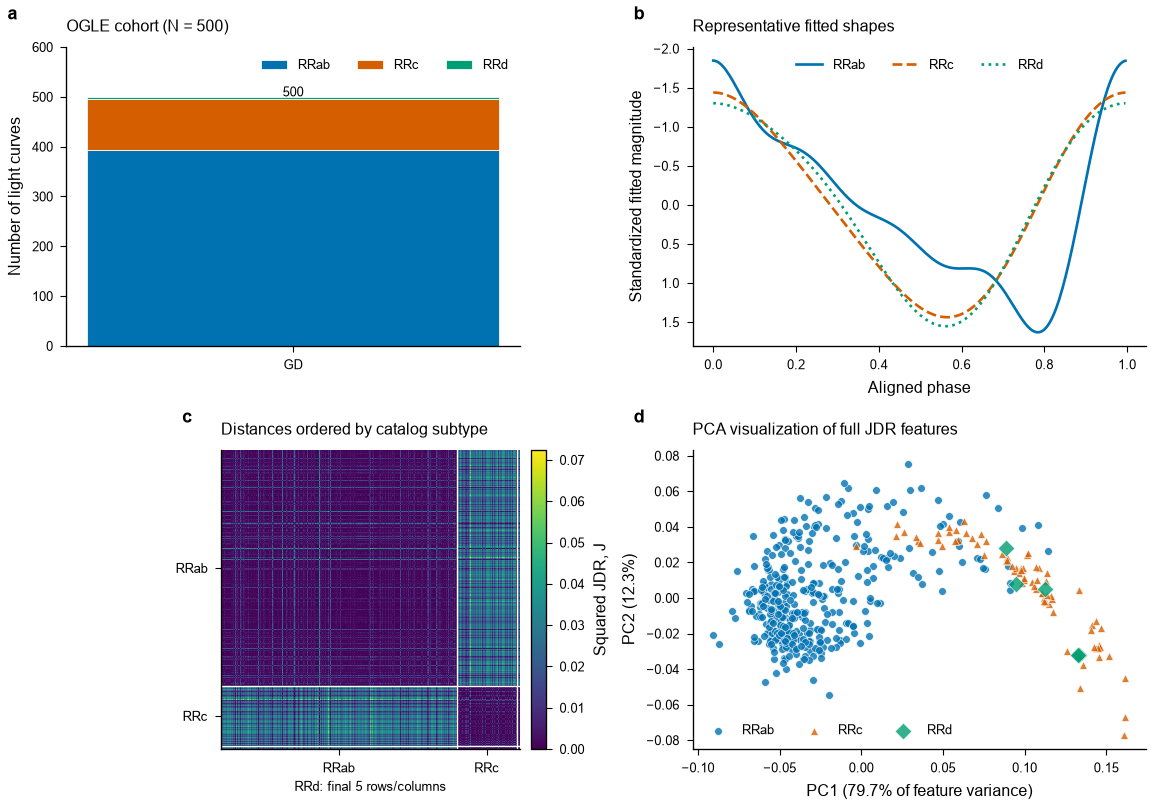

Figure 1 | Seeded OGLE Galactic Disk cohort and JDR geometry. a, Catalog composition by sky region (BLG, Galactic bulge; GD, Galactic disk; LMC, Large Magellanic Cloud). All 500 selected eligible I-band curves are included; GD denotes Galactic disk. b, Standardized, fitted periodic shapes of within-subtype distance medoids, selected for display only; these are model fits, not raw photometry or uncertainty bands. c, Squared-JDR matrix ordered by catalog subtype, then region and ID; the small RRd block is indicated. Clustering uses sqrt(J). d, Two-component PCA of the full spectral embedding, colored by catalog subtype. PCA is used only for visualization; all clustering uses the full embedding or its distances. Source IDs, display order and values are exported. RRd has only 5 objects.

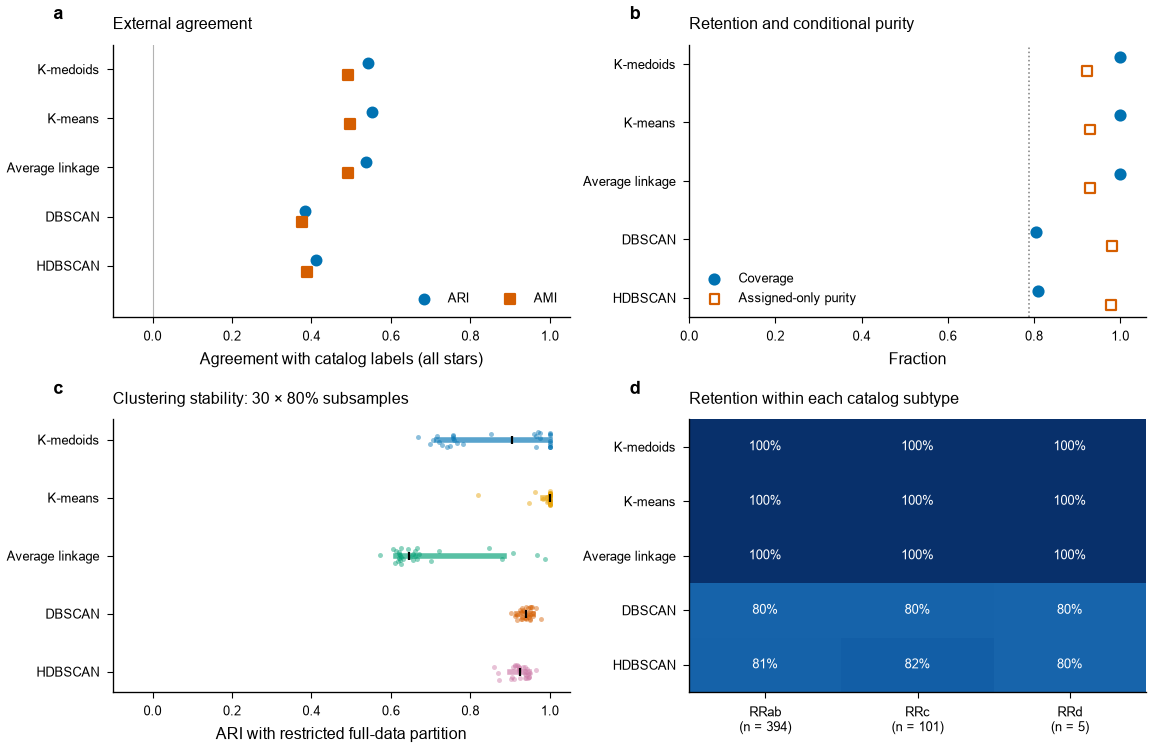

Figure 2 | Comparison under the fixed protocol. a, Adjusted Rand index (ARI) and adjusted mutual information (AMI) against catalog labels, evaluated on all 500 objects; rejected points share label −1. b, Assigned fraction and purity conditional on assignment; dotted line is the 0.788 majority-class fraction, not a performance threshold. c, Clustering is refitted on 30 reproducible, shared 400-object subsets using fixed policies; dots are replicate ARIs against the full partition restricted to the subset, thick segments show empirical 10th–90th percentiles and black ticks show medians. These are stability summaries, not confidence intervals, independent repetitions of data collection, or photometric/period uncertainty propagation. DBSCAN recalculates its prescribed distance quantile within each subset. d, Within-subtype retention, with denominators shown. A 100% value for the 5 RRd objects is not evidence of generalizable RRd recovery.

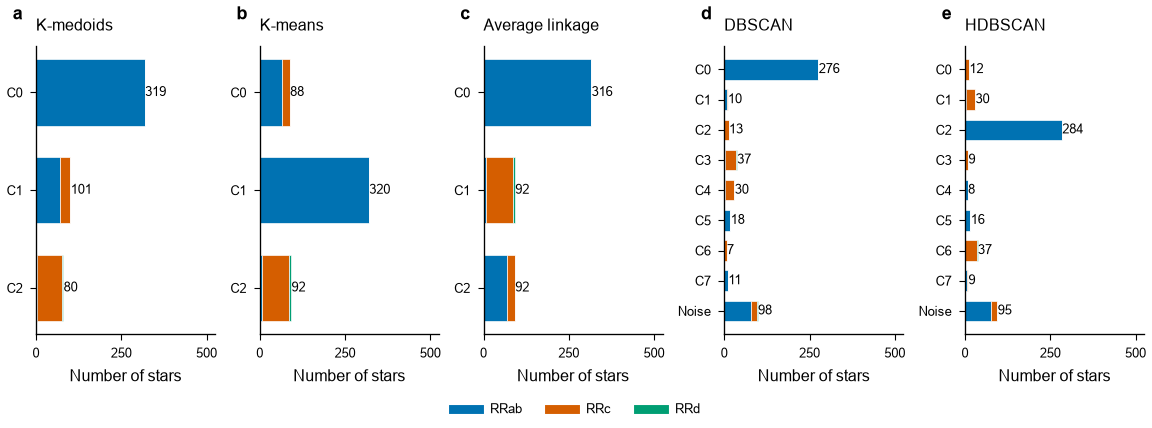

Figure 3 | Catalog composition of every learned cluster. Bar segments are observed counts, colors denote catalog subtype, and end labels give total cluster size. Each method has its own arbitrary cluster IDs; similarly numbered clusters are not asserted to correspond. Noise is displayed explicitly where present. All panels share a 0–525 count axis. No cluster-to-class relabeling or removal of rejected observations was used.

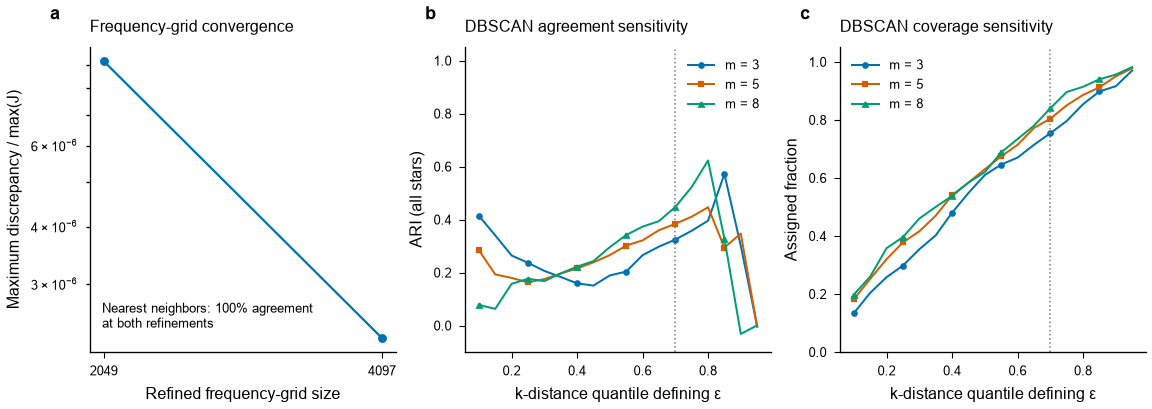

Figure 4 | Numerical and parameter checks. a, Successive refinements from 1025 to 2049 to 4097 frequencies compare squared-JDR matrices; every entry also satisfies rtol=10⁻³ and atol=10⁻⁸. Nearest-neighbor identities are unchanged. b,c, The full, predeclared DBSCAN sensitivity grid: neighborhood size m∈{3,5,8}, including the observation itself, and 18 k-distance quantiles from 0.10 to 0.95. The dotted line marks the primary quantile 0.70; the primary model has m=5. These external-score curves are post-fit diagnostics, not used to choose the reported model. The cohort is an exploratory seeded sample, not held-out evaluation.

In [7]:
figure_directory = make_figures(OUTPUT)
captions = json.loads((figure_directory / 'captions.json').read_text())
for stem, caption in captions.items():
    display(Image(filename=str(figure_directory / f'{stem}_preview.png')))
    display(Markdown(caption))

## 8. Interpretation, limitations and next experiments

This experiment validates the computation and its repeatability in the recorded environment. It does not establish that the resulting clusters are physical classes, that a particular method is significantly superior, or that the result generalizes to other regions/bands.

Only five RRd stars are included; the sample is dominated by RRab. A single-period, at-most-four-harmonic fit cannot represent all double-mode or modulated stars. Normalization removes potentially useful amplitude and period information. The fixed spectral band, alignment, period limits and known $K=3$ assumption are methodological choices. Thirty subsamples do not propagate measurement errors or period uncertainty. All catalog scores are in-sample descriptive comparisons; no best-model significance test is claimed.

Next studies should predeclare a separate validation cohort, inspect period-disagreement cases against the raw data, propagate photometric/period uncertainty through the entire pipeline, fit multiple modes where justified, and compare shape-only clustering with explicit period/amplitude features and alternative phase alignment. Band/harmonic sensitivity should be evaluated without selecting settings on the held-out catalog labels. A stratified rare-class study would answer a different question and must retain its sampling weights and selection rationale.

The original catalog and paper remain the authoritative source for object identities and astrophysical classification. The implementation’s standard v2 spectral convention and integral normalization are stated above so they can be reviewed without assuming equivalence to a particular theoretical JDR formulation.

In [8]:
provenance = json.loads((OUTPUT / 'provenance.json').read_text())
display(pd.Series(provenance['versions'], name='Recorded package version').to_frame())
display(pd.DataFrame({'artifact': ['cohort.csv', 'experiment.npz', 'model_comparison.csv', 'cluster_labels.csv', 'period_candidates.json', 'period_audit.csv', 'spectral_integral_audit.csv', 'subsampling_stability.csv', 'subsample_membership.json', 'dbscan_sensitivity.csv', 'provenance.json', 'additional_checks.json', 'reproducibility.json', 'timing.json', 'repeat_timing.json', 'figures/CAPTIONS.md']}))
print('Completed 500-curve experiment:', OUTPUT)

,Recorded package version
numpy,2.5.3
scipy,1.18.1
pandas,3.0.5
scikit-learn,1.9.1
astropy,8.0.1
matplotlib,3.11.2
threadpoolctl,3.6.0


,artifact
0,cohort.csv
1,experiment.npz
2,model_comparison.csv
3,cluster_labels.csv
4,period_candidates.json
5,period_audit.csv
6,spectral_integral_audit.csv
7,subsampling_stability.csv
8,subsample_membership.json
9,dbscan_sensitivity.csv


Completed 500-curve experiment: /Users/francisco/code/JDR-Python/results/benchmark_500
